- Learning how to make micrograd from karpathy
- It is a scalar valued automatic gradient (autograd) engine 

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

$$f(x) = 3x^2 - 4x + 5$$

In [2]:
def f(x):
    return 3*x**2 - 4*x + 5

In [3]:
f(3.00)

20.0

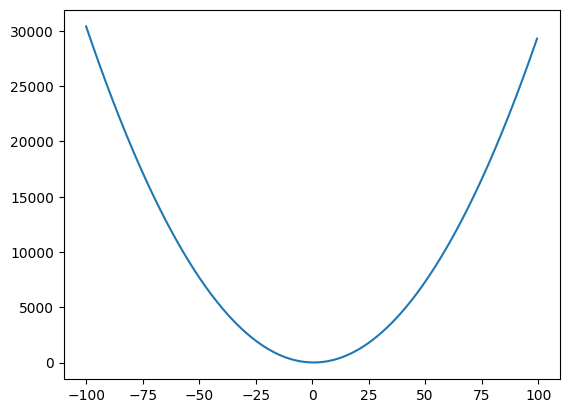

In [4]:
xs = np.arange(-100, 100, 0.5)
ys = f(xs)
plt.plot(xs, ys)    

- f(x) is a parabola when graphed (quadratic)

In [5]:
# Calculating gradient difference between x and x+h with h=0.001 (derivative definition)
h = 0.0001
x = 2/3
print(f(x+h))
print((f(x+h) - f(x))/h)

3.666666696666667
0.0002999999981767587


- The definition of a derivative is: 

$$f'(x) = \lim_{h \to 0} \frac{f(x+h)-f(x)}{h}$$

- Actual derivative of given f(x) would be: 

$$f'(x) = 6x - 4$$

- Therefore, 
$$f'(3) =14$$

In [6]:
# A more complex function

a = 2.0
b = -3.0
c = 10.0
d = a * b + c

print(d)

4.0


In [7]:
h = 0.0001

# inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a * b + c

a += h
d2 = a * b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h)

d1 4.0
d2 3.999699999999999
slope -3.000000000010772


In [8]:
h = 0.0001

# inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a * b + c

b += h
d2 = a * b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h)

d1 4.0
d2 4.0002
slope 2.0000000000042206


In [9]:
h = 0.0001

# inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a * b + c

c += h
d2 = a * b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h)

d1 4.0
d2 4.0001
slope 0.9999999999976694


In [10]:
# Defining mathematical primitive object Value

class Value():

    def __init__(self, data, _children=(), _op=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op

    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out 
    

a = Value(2.0)
b = Value(-3.00)
c = Value(10.0)
d = a*b+c
print(d)

# d is equivalent to
a.__mul__(b).__add__(c)

Value(data=4.0)


Value(data=4.0)

In [11]:
d._prev

{Value(data=-6.0), Value(data=10.0)}

In [12]:
d._op

'+'

In [13]:
# The code for visualising the computational graph

from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in the graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  #LR = Left to Right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ data %.4f }" % (n.data, ), shape='record')

        if n._op:
            # If this value is the result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot


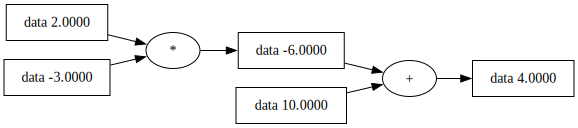

In [14]:
draw_dot(d)